# Day 3 Machine Learning

# Supervised Learning

## Linear Regression

### Import Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
import warnings
warnings.filterwarnings('ignore')

Reading Data


In [4]:
df=pd.read_csv('/content/drive/MyDrive/AI ML/green skill (24-29)/appliance_energy.csv')
df.head()

,Temperature (°C),Energy Consumption (kWh)
0,22.490802,2.292604
1,34.014286,3.251925
2,29.639879,3.009868
3,26.973170,1.703533
4,18.120373,1.702201


In [5]:
df.describe()

,Temperature (°C),Energy Consumption (kWh)
count,100.000000,100.000000
mean,24.403615,2.439821
std,5.949788,0.693527
min,15.110442,0.978107
25%,18.864015,1.908640
50%,24.282849,2.364121
75%,29.604062,2.931199
max,34.737739,4.159094


In [6]:
df.shape

(100, 2)

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature (°C)          100 non-null    float64
 1   Energy Consumption (kWh)  100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [10]:
df.tail()

,Temperature (°C),Energy Consumption (kWh)
95,24.875912,2.079686
96,25.454657,2.506915
97,23.550820,2.525658
98,15.508383,1.689184
99,17.157829,2.129374


### Data Training


In [26]:
df.columns

Index(['Temperature (°C)', 'Energy Consumption (kWh)'], dtype='object')

In [27]:
X=df[['Temperature (°C)']]
y=df['Energy Consumption (kWh)']

In [28]:
X

,Temperature (°C)
0,22.490802
1,34.014286
2,29.639879
3,26.973170
4,18.120373
...,...
95,24.875912
96,25.454657
97,23.550820
98,15.508383


In [38]:
X_train,X_test,y_train,y_test=tts(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80, 1)
(20, 1)
(80,)
(20,)


### Model Training and Testing

In [35]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [39]:
y_pred = model.predict(X_test)
y_pred

array([1.6858187 , 3.18154068, 2.96097494, 2.76354868, 2.0370856 ,
       2.36343345, 2.09711944, 3.12445907, 1.60849483, 2.24537556,
       2.34866555, 2.66462648, 3.0387357 , 3.27880886, 1.78664542,
       1.85218469, 2.95922164, 1.70468695, 3.0692904 , 1.87828475])

In [41]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
r2=r2_score(y_test, y_pred)
print("R2 Score:", r2)

Mean Squared Error: 0.16342487842925055
R2 Score: 0.6119478445218713


### Data Visulization

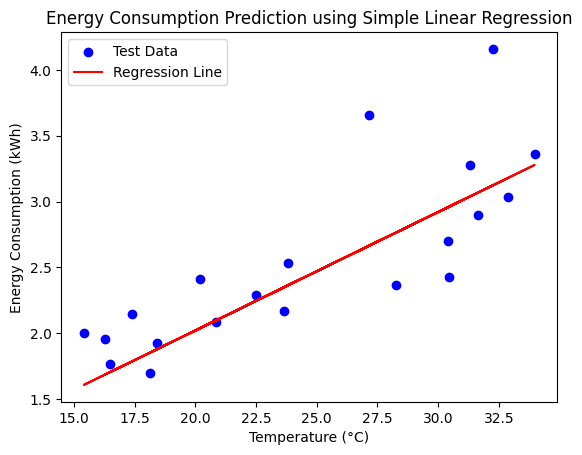

In [45]:
plt.scatter(X_test, y_test, color='blue', label='Test Data')
plt.plot(X_test, y_pred, color='red',label='Regression Line')
plt.title('Energy Consumption Prediction using Simple Linear Regression')
plt.xlabel('Temperature (°C)')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.show()

### Saving Model

In [46]:
import joblib

In [47]:
joblib.dump(model,'appliance_energy_model.pkl')

['appliance_energy_model.pkl']

### Prediction Model

In [52]:
model = joblib.load('appliance_energy_model.pkl')
def predict(temperature):
  prediction = model.predict(np.array([[temperature]]))
  return prediction[0]

temperature = int(input("Enter Temprature :"))
predicted_energy_consumption = predict(temperature)
print(f"Predicted energy consumption at {temperature}°C: {predicted_energy_consumption} kWh")


Enter Temprature :40
Predicted energy consumption at 40°C: 3.820611231579629 kWh


## Logistic Regression

### Improting Data

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
import seaborn as sns


In [54]:
data = pd.read_csv('/content/drive/MyDrive/AI ML/green skill (24-29)/green_tech_data[1].csv')

Reading Data

In [60]:
data.head()

,carbon_emissions,energy_output,renewability_index,cost_efficiency,sustainability
0,181.089042,128.286267,0.642032,0.732568,1
1,382.750007,672.769370,0.084140,2.891096,0
2,306.197880,382.920383,0.161629,2.932858,0
3,259.530469,557.713622,0.898554,3.368435,0
4,104.606524,916.809827,0.606429,3.767411,0


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['carbon_emissions'].plot(kind='hist', bins=20, title='carbon_emissions')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['energy_output'].plot(kind='hist', bins=20, title='energy_output')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['renewability_index'].plot(kind='hist', bins=20, title='renewability_index')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['index']
  ys = series['sustainability']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('sustainability')

from matplotlib import pyplot as plt
_df_12['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['carbon_emissions'].plot(kind='line', figsize=(8, 4), title='carbon_emissions')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['energy_output'].plot(kind='line', figsize=(8, 4), title='energy_output')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['renewability_index'].plot(kind='line', figsize=(8, 4), title='renewability_index')
plt.gca().spines[['top', 'right']].set_visible(False)

In [61]:
data.describe()

,carbon_emissions,energy_output,renewability_index,cost_efficiency,sustainability
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,214.563260,548.048551,0.517601,2.710170,0.15000
std,104.121294,263.800127,0.293426,1.320535,0.35887
min,51.932741,106.256917,0.005062,0.564771,0.00000
25%,117.620266,317.804074,0.276880,1.623267,0.00000
50%,212.449859,555.062371,0.562555,2.793732,0.00000
75%,305.571092,789.565238,0.752367,3.810999,0.00000
max,395.410428,987.085409,0.990054,4.957273,1.00000


In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   carbon_emissions    100 non-null    float64
 1   energy_output       100 non-null    float64
 2   renewability_index  100 non-null    float64
 3   cost_efficiency     100 non-null    float64
 4   sustainability      100 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 4.0 KB


In [63]:
data.shape

(100, 5)

In [64]:
data.isna().sum()

,0
carbon_emissions,0
energy_output,0
renewability_index,0
cost_efficiency,0
sustainability,0


In [66]:
data.describe(include='all')

,carbon_emissions,energy_output,renewability_index,cost_efficiency,sustainability
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,214.563260,548.048551,0.517601,2.710170,0.15000
std,104.121294,263.800127,0.293426,1.320535,0.35887
min,51.932741,106.256917,0.005062,0.564771,0.00000
25%,117.620266,317.804074,0.276880,1.623267,0.00000
50%,212.449859,555.062371,0.562555,2.793732,0.00000
75%,305.571092,789.565238,0.752367,3.810999,0.00000
max,395.410428,987.085409,0.990054,4.957273,1.00000


### Data Training

In [67]:
data.columns

Index(['carbon_emissions', 'energy_output', 'renewability_index',
       'cost_efficiency', 'sustainability'],
      dtype='object')

In [68]:
X1 = data[['carbon_emissions', 'energy_output', 'renewability_index',
       'cost_efficiency']]
y1 = data['sustainability']

### Training and Testing

In [69]:
X1_train,X1_test,y1_train,y1_test=tts(X1,y1,test_size=0.2,random_state=42)
print(X1_train.shape)
print(X1_test.shape)
print(y1_train.shape)
print(y1_test.shape)

(80, 4)
(20, 4)
(80,)
(20,)


### Model Creation

In [70]:
model1 = LogisticRegression()
model1.fit(X1_train, y1_train)

LogisticRegression()

In [71]:
y1_pred = model1.predict(X1_test)
y1_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

### Evalation of Model

In [74]:
accuracy = accuracy_score(y1_test, y1_pred)
print("Accuracy:", accuracy)

class_report = classification_report(y1_test, y1_pred)
print("\n\nClassification Report:\n", class_report)

conf_matrix = confusion_matrix(y1_test, y1_pred)
print("\n\nConfusion Matrix:\n", conf_matrix)

Accuracy: 0.95


Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        17
           1       1.00      0.67      0.80         3

    accuracy                           0.95        20
   macro avg       0.97      0.83      0.89        20
weighted avg       0.95      0.95      0.95        20



Confusion Matrix:
 [[17  0]
 [ 1  2]]


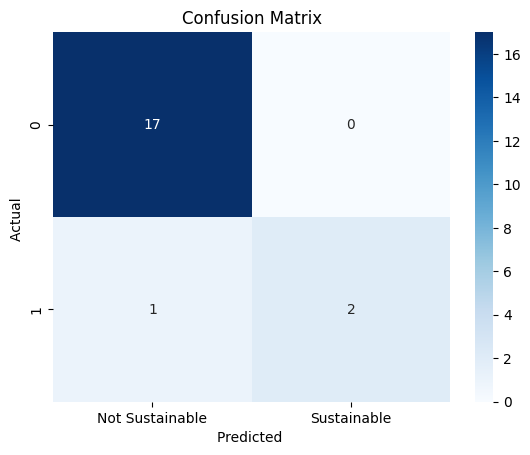

In [83]:
conf_matrix=confusion_matrix(y1_test, y1_pred)
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
xticklable=['Not Sustainable','Sustainable']
yticklable=['Not Sustainable','Sustainable']
plt.xticks(np.arange(2)+0.5,xticklable)
plt.xlabel('Predicted ')
plt.ylabel('Actual ')
plt.show()



In [87]:
print(classification_report(y1_test,y1_pred,target_names=['Not Sustainable','Sustainable']))

                 precision    recall  f1-score   support

Not Sustainable       0.94      1.00      0.97        17
    Sustainable       1.00      0.67      0.80         3

       accuracy                           0.95        20
      macro avg       0.97      0.83      0.89        20
   weighted avg       0.95      0.95      0.95        20



In [90]:
coefficients = pd.DataFrame(model1.coef_.T, index=X1.columns, columns=['Coefficient'])
print(coefficients)

                    Coefficient
carbon_emissions      -0.023347
energy_output          0.001097
renewability_index     1.092184
cost_efficiency       -1.259560


### Model Saving

In [75]:
joblib.dump(model1,'green_tech_data_model.pkl')

['green_tech_data_model.pkl']

### Prediction Model

In [79]:
model1 = joblib.load('green_tech_data_model.pkl')

def predict_sustainability(carbon_emissions, energy_output, renewability_index, cost_efficiency):

  prediction = model1.predict(np.array([[carbon_emissions, energy_output, renewability_index, cost_efficiency]]))
  return prediction[0]



carbon_emissions = float(input("Enter carbon emissions: "))
energy_output = float(input("Enter energy output: "))
renewability_index = float(input("Enter renewability index: "))
cost_efficiency = float(input("Enter cost efficiency: "))

predicted_sustainability = predict_sustainability(carbon_emissions, energy_output, renewability_index, cost_efficiency)
print(f"Predicted sustainability: {predicted_sustainability}")


Enter carbon emissions: 10
Enter energy output: 120
Enter renewability index: 0.4
Enter cost efficiency: 0.8
Predicted sustainability: 1
